In [3]:
import pickle
import joblib
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [4]:
df = pd.read_csv("housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [6]:
df.shape


(20640, 10)

In [14]:
df = df.iloc[: , :-1]

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [16]:
df.dropna()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0


In [40]:
X = df.drop(columns = "median_house_value")
y = df.median_house_value.copy()
print(X.shape, y.shape)

(20640, 8) (20640,)


In [41]:
X.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
dtype: int64

<Axes: >

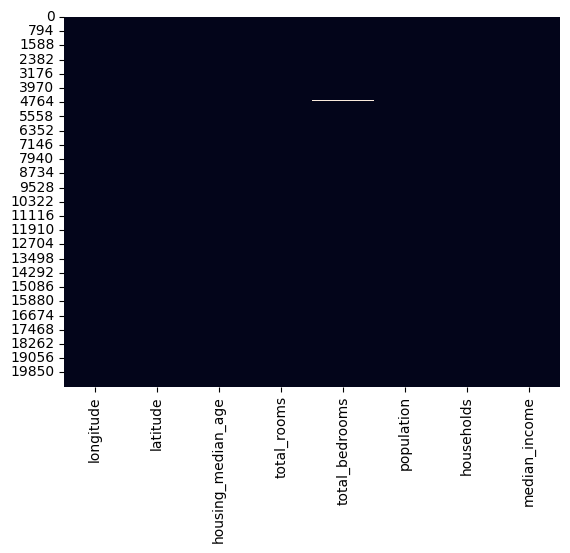

In [42]:
import seaborn as sns
sns.heatmap(X.isnull(), cbar=False)

In [43]:
# X = X.drop(columns ="total_bedrooms" )
X = X.fillna(X["total_bedrooms"].mean())

In [44]:
X.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
dtype: int64

In [45]:
X.shape

(20640, 8)

In [46]:
model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [47]:
y_pred = model.predict(X)
y_pred
     

array([408842.17960578, 420686.26396955, 378825.44096113, ...,
        25861.35779259,  38316.94044144,  55200.426262  ])

In [48]:
r2_score(y, y_pred)


0.635640226342306

In [49]:
model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [50]:
with open('model.pkl', 'wb') as f:
  pickle.dump(model, f)

In [51]:
with open('model.pkl', 'rb') as f:
  pickle_model = pickle.load(f)
     

In [52]:
pickle_model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [53]:
y_pred_pickle = pickle_model.predict(X)
y_pred_pickle

array([408842.17960578, 420686.26396955, 378825.44096113, ...,
        25861.35779259,  38316.94044144,  55200.426262  ])

In [54]:
r2_score(y, y_pred_pickle)


0.635640226342306

In [55]:
joblib.dump(model, 'model.joblib')


['model.joblib']

In [56]:
joblib_model = joblib.load('model.joblib')
joblib_model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [57]:
y_pred_joblib = joblib_model.predict(X)
y_pred_joblib

array([408842.17960578, 420686.26396955, 378825.44096113, ...,
        25861.35779259,  38316.94044144,  55200.426262  ])

In [58]:
r2_score(y, y_pred_joblib)


0.635640226342306